# Predictive Alerting for Cloud Metrics: Solution Analysis

This notebook provides a detailed walkthrough of the modeling choices, evaluation setup, and result analysis for the predictive alerting pipeline.

The entire data generation, feature engineering, and model training pipeline has been executed via the Python scripts in the `src/` directory. Here, we analyze the final outcomes and address real-world adaptations.

## 1. Problem Formulation & Methodology

The goal is to predict an incident within a future horizon of $H = 10$ minutes based on a window of $W = 30$ minutes of past data.

* **Features:** Instead of using raw time series, we extract statistical aggregates (mean, std, min, max, last, diff) from the 30-minute sliding window to reduce dimensionality.
* **Models Tested:** Logistic Regression (Baseline) and Random Forest (Primary). Random Forest was chosen for the final evaluation due to its ability to handle non-linear relationships between metrics.
* **Validation:** A strict time-based split (70% Train, 15% Validation, 15% Test) without shuffling was used to completely prevent data leakage from the future.

--- Data Generation: Metric Degradation Example ---


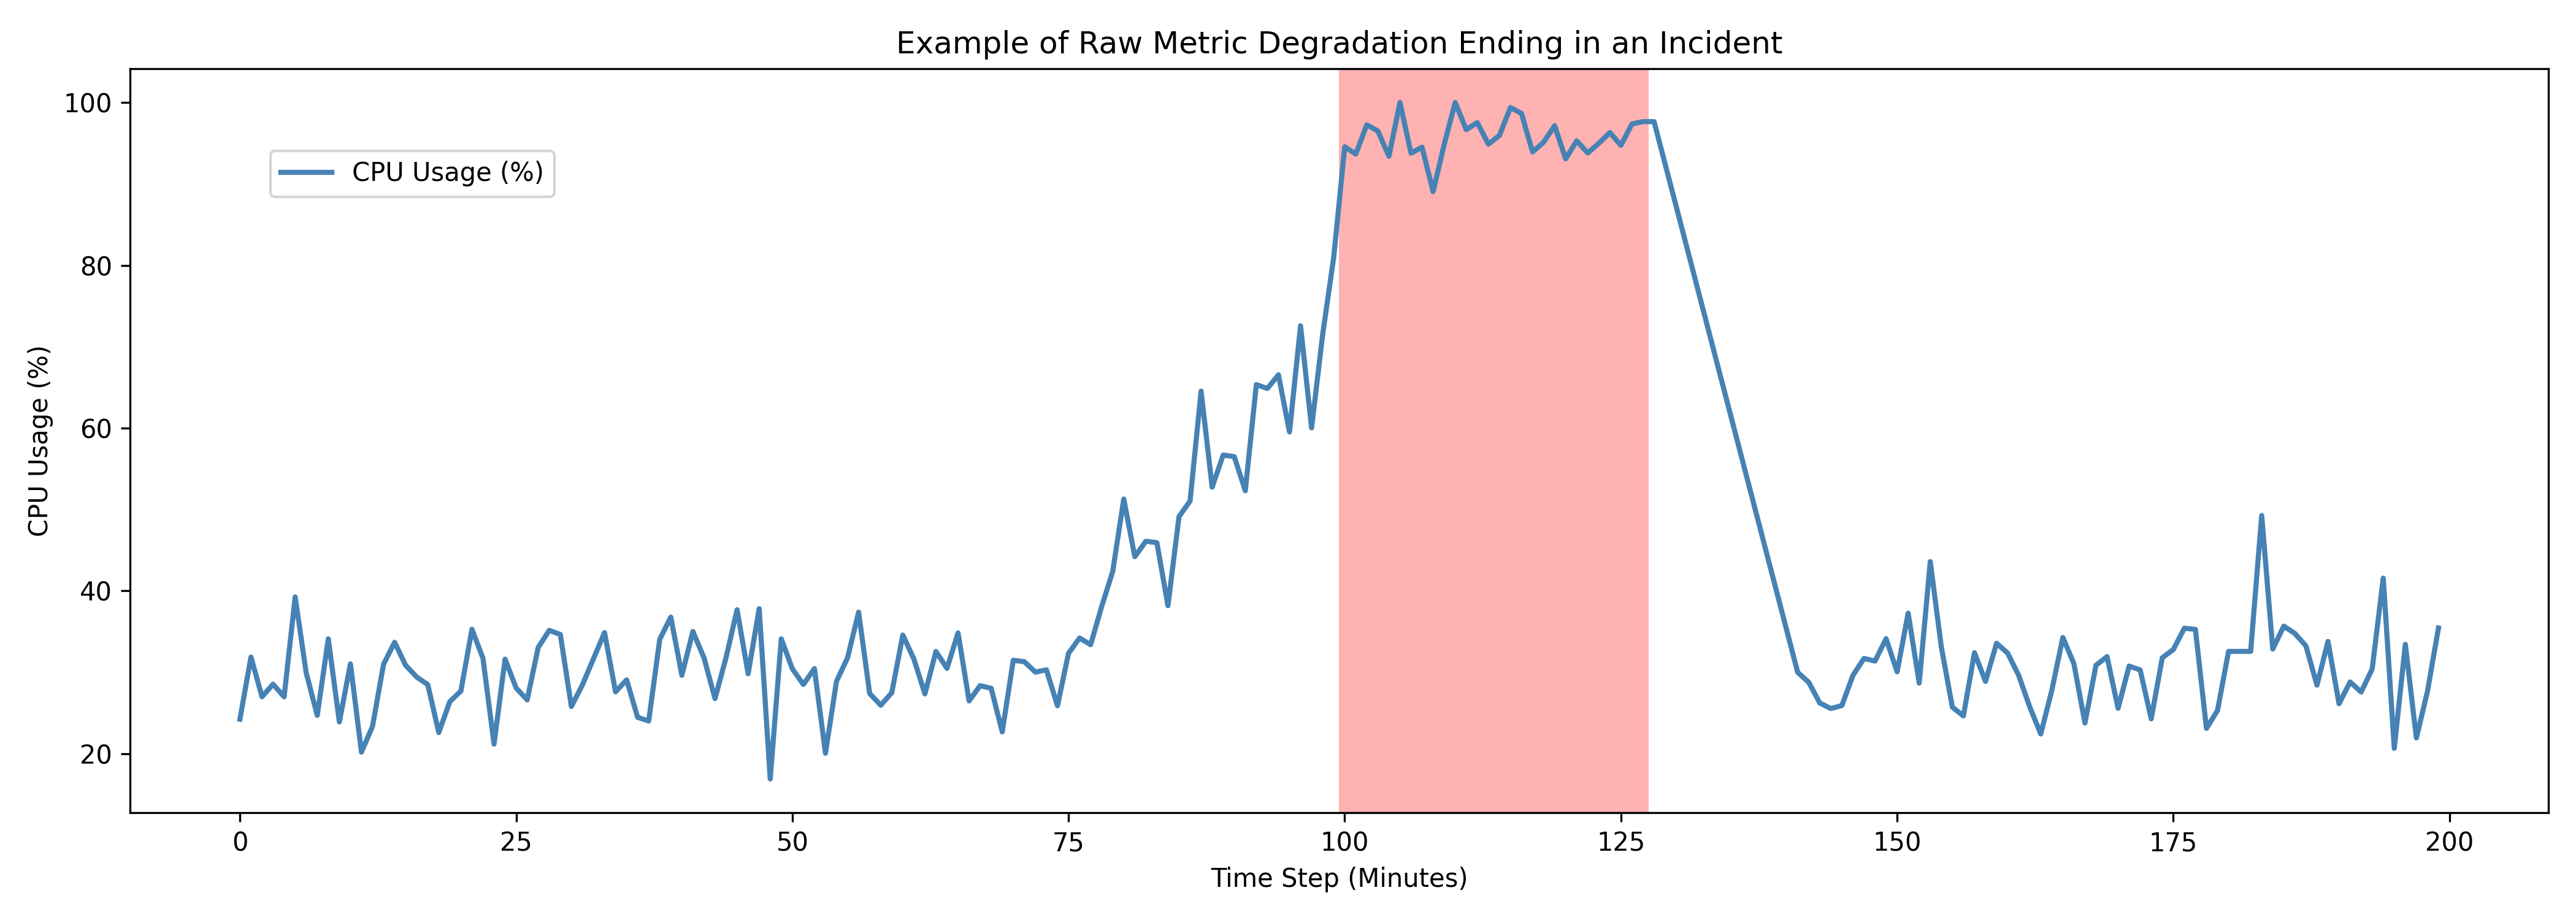

In [7]:
from IPython.display import Image, display

print("--- Data Generation: Metric Degradation Example ---")
display(Image(filename='../figures/metrics_incidents.png'))

## 2. Evaluation Setup & Metrics

Because cloud monitoring datasets are highly imbalanced (~95% normal operations, ~5% incident windows), standard accuracy is misleading. Instead, we focus on:

* **Precision:** If the model triggers an alert, what is the probability it's a real incident? High precision minimizes *alert fatigue*.
* **Recall:** What percentage of actual incidents did we successfully catch in advance? High recall minimizes *system downtime*.
* **PR AUC (Precision-Recall Area Under Curve):** The primary metric for this task. It summarizes the trade-off between Precision and Recall across all possible alert thresholds. We prefer PR AUC over ROC AUC because ROC AUC can be overly optimistic on heavily imbalanced datasets.

--- Model Performance: Precision-Recall Curve ---


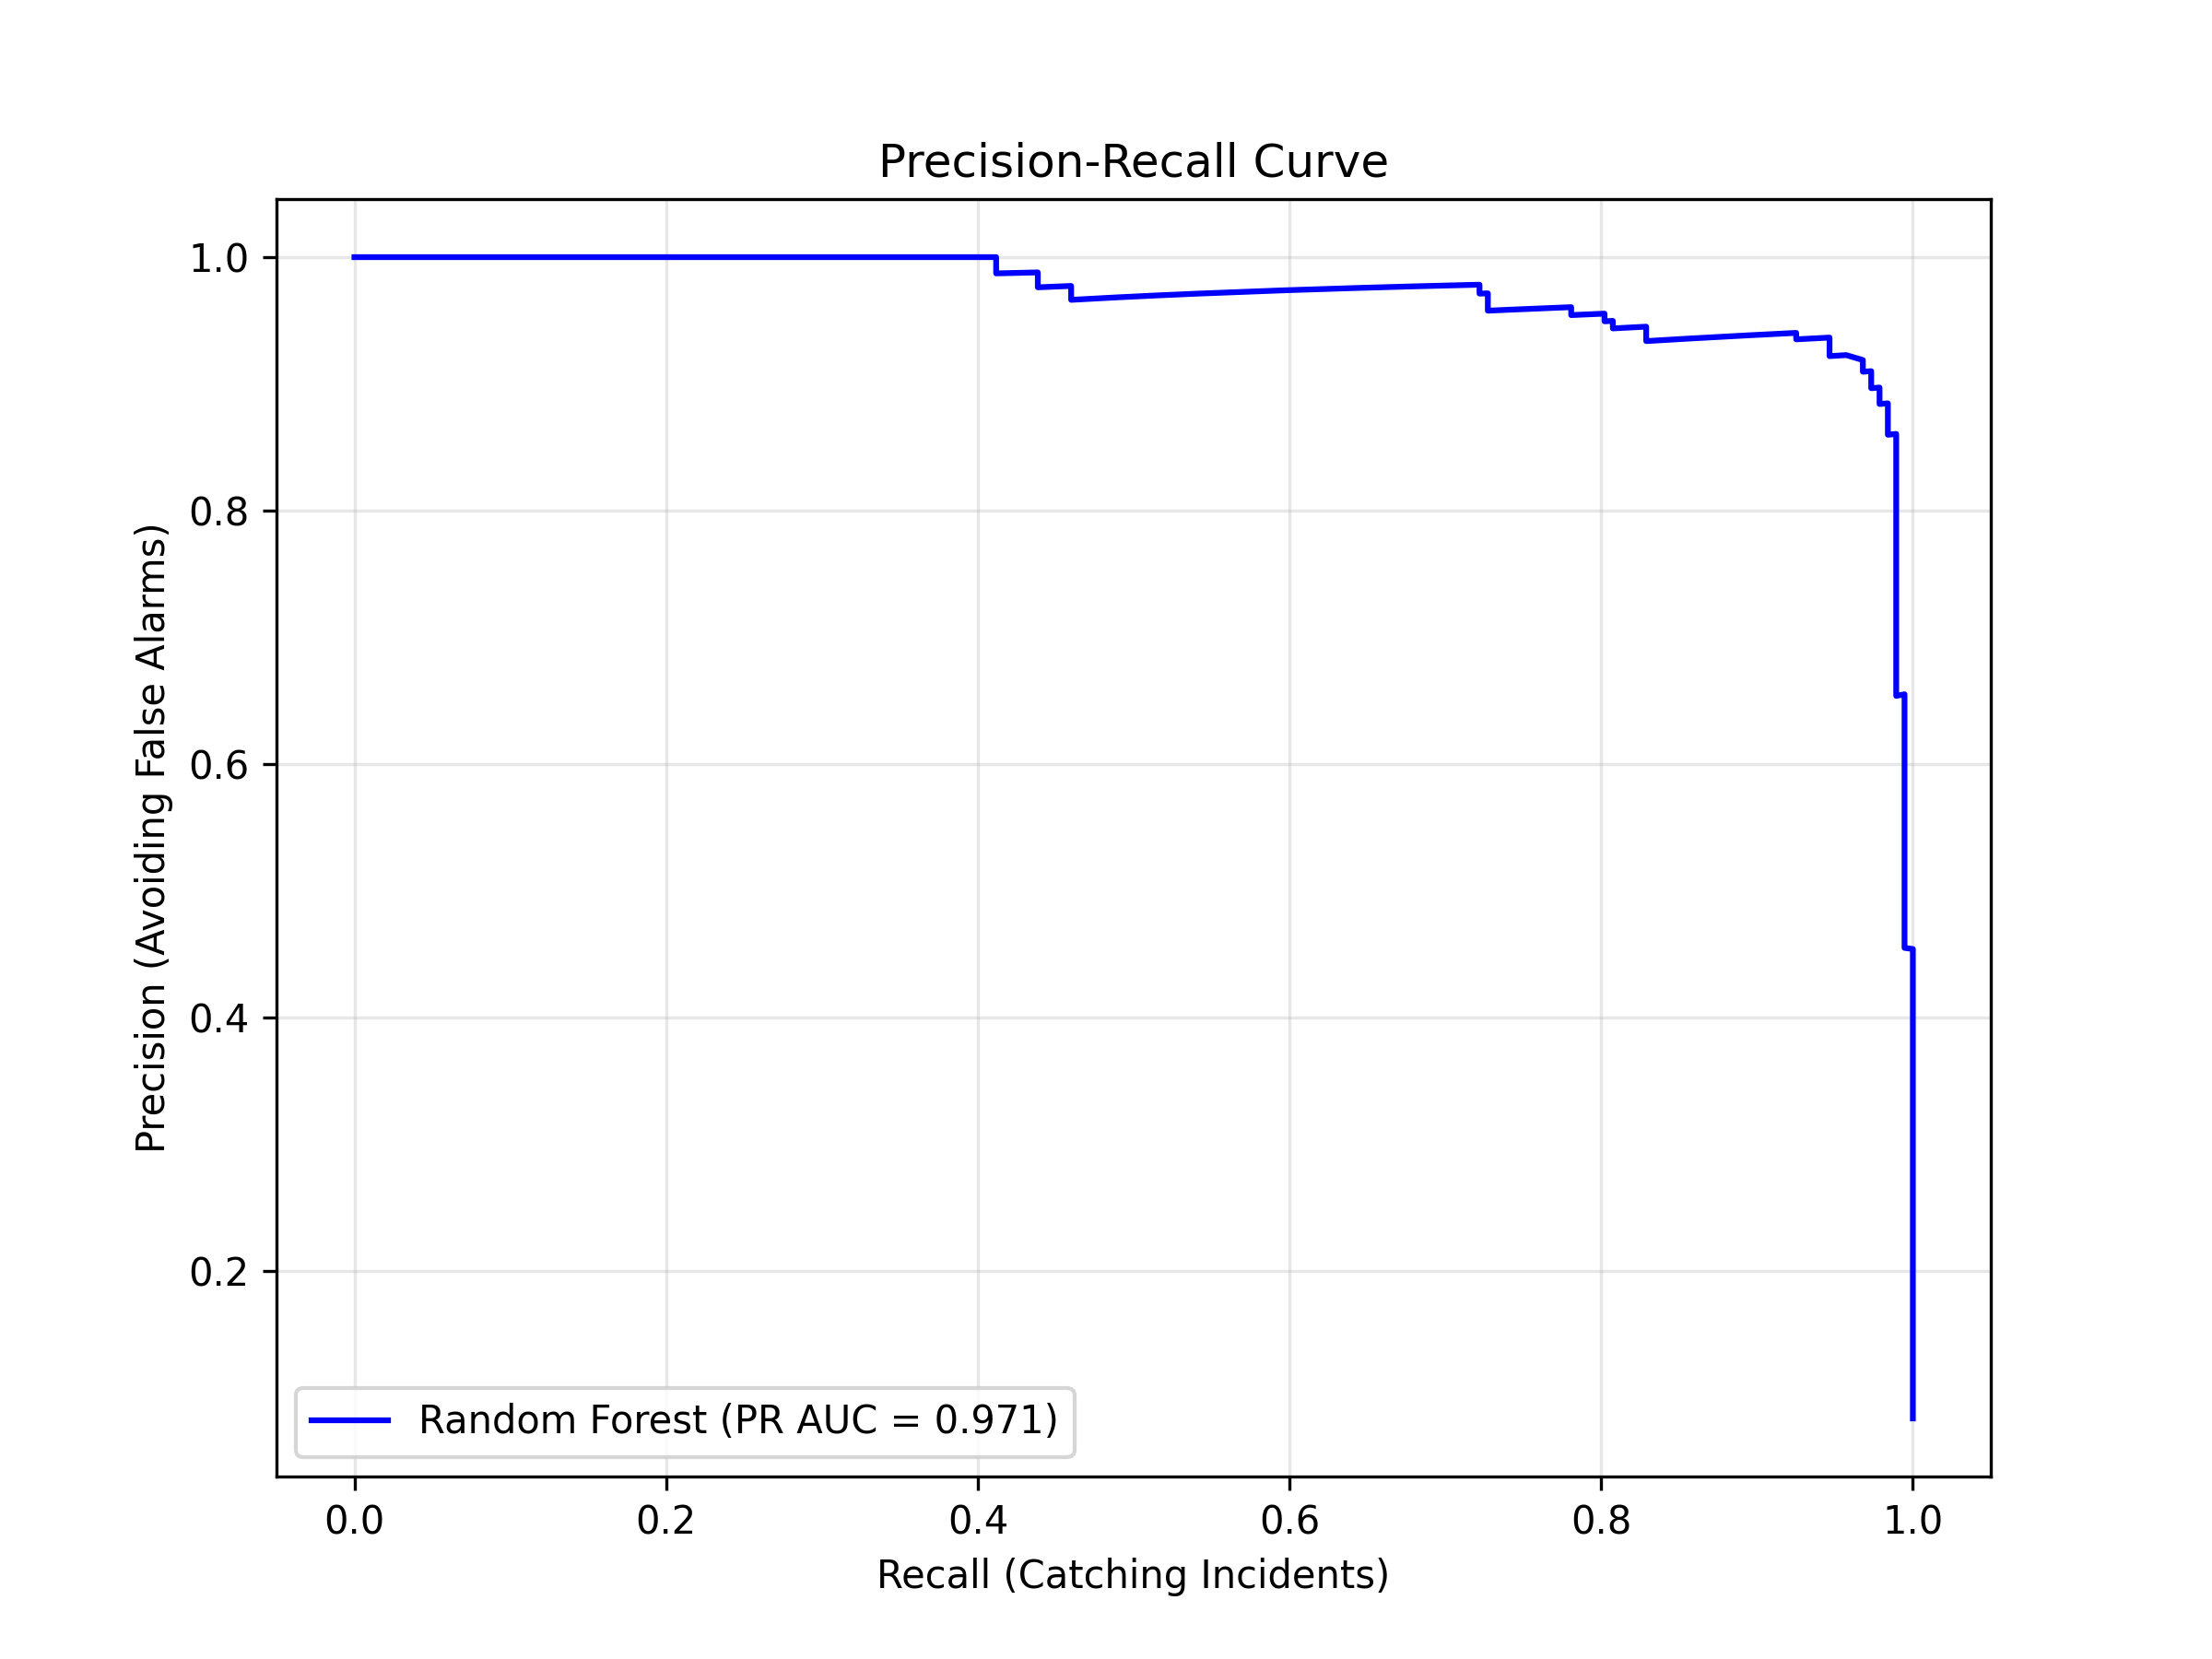

In [8]:
print("--- Model Performance: Precision-Recall Curve ---")
display(Image(filename='../figures/pr_curve.png'))

## 3. Analysis & Threshold Selection

As seen in the PR Curve above, there is a clear trade-off between catching every incident and spamming the on-call engineers. By default, the Random Forest decision threshold is 0.5. 

* **Lowering the threshold (e.g., to 0.3):** Increases **Recall** (we catch more incidents) but drops **Precision** (we generate more false alarms). This is suitable for mission-critical components (e.g., payment gateways) where missing an incident is unacceptable.
* **Raising the threshold (e.g., to 0.8):** Increases **Precision** (alerts are almost certainly real) but lowers **Recall** (we risk missing subtle degradations). This is suitable for non-critical background workers where alert fatigue is a bigger risk than a temporary slowdown.

--- Alerting Timeline: Predicted Risk vs Actual Incidents ---


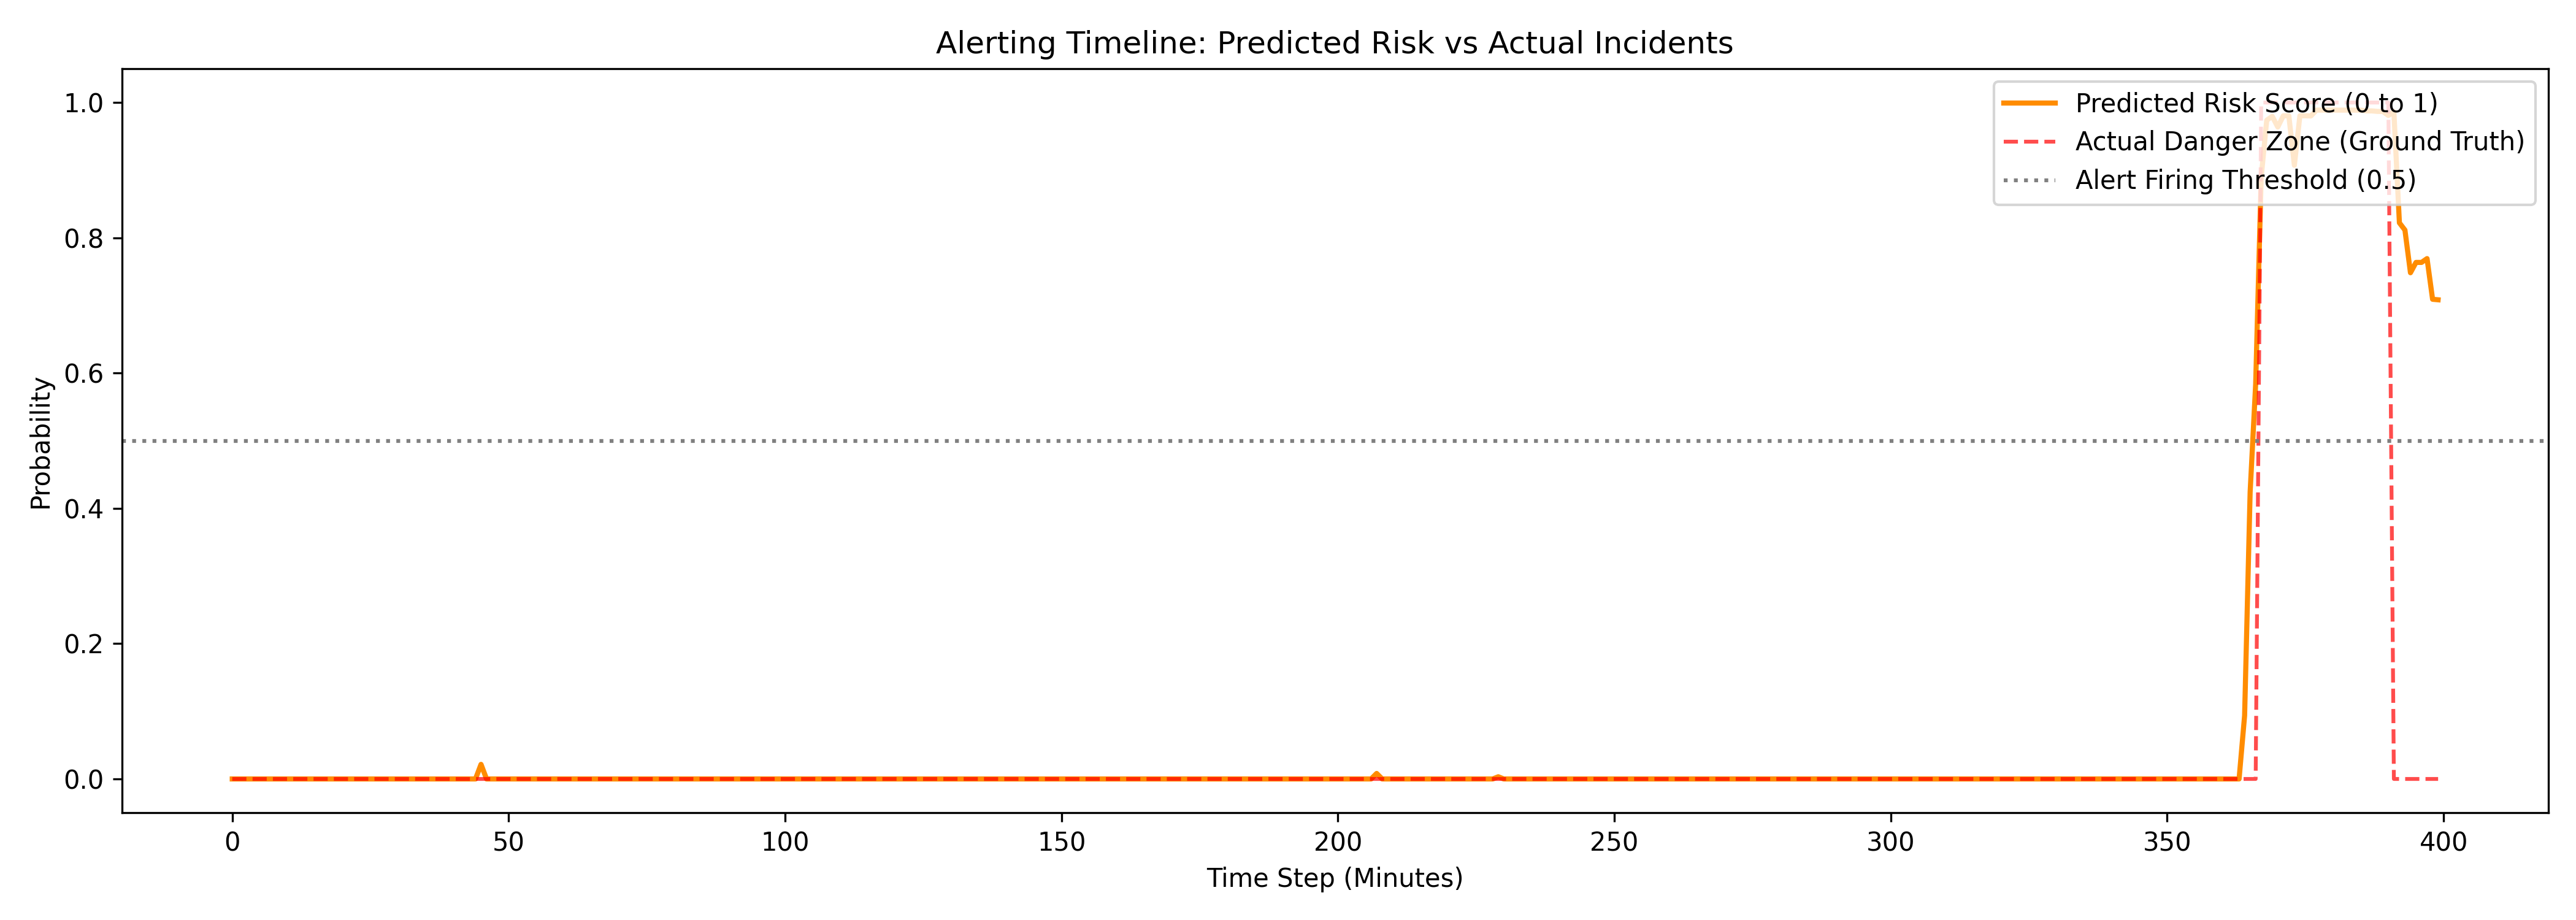

In [9]:
print("--- Alerting Timeline: Predicted Risk vs Actual Incidents ---")
display(Image(filename='../figures/risk_scores.png'))

## 4. Limitations & Real-World Adaptation

To adapt this approach to a real production alerting system (as requested in the task follow-up), several limitations must be addressed:

1. **Static Windows vs Dynamic Horizons:** Currently, $W$ and $H$ are fixed. In a real system, incidents develop at different speeds (a memory leak might take days, a network spike takes seconds). We could adapt this by using multiple window sizes concurrently (e.g., 5m, 30m, 2h) or by utilizing sequence models (LSTMs/Transformers).
2. **Concept Drift:** Synthetic data is stationary. In reality, cloud infrastructure behavior changes after new code deployments or configuration changes. A real alerting system would need continuous retraining (online learning) to refresh the model when the data distribution shifts.
3. **Multivariate Complexities:** The current model assumes metrics exist on a single isolated node. A real adaptation would involve graph-based features or distributed tracing data to correlate metrics across various microservices and database shards.